# FPFS on Blended Galaxies with the new `anacal.task.Task` API

This notebook reproduces `example_fpfs_blended.ipynb`, but replaces the
legacy `anacal.fpfs.process_image` detection/measurement with the newer
`anacal.task.Task` interface.

`anacal.task.Task` is the same engine driven by
`xlens.processor.anacal.AnacalTask` (see
`xlens/xlens/processor/anacal.py`), which is in turn called by
`xlens.processor.measure_coadds.MeasureCoaddsPipe`. Here we call it
directly on the raw image/PSF arrays — no LSST stack required.

The workflow is:
1. Read the **same** `gal.fits` and `psf.fits` as the legacy example.
2. Build a list of processing blocks with `anacal.geometry.get_block_list`
   and attach the (constant) PSF to each block.
3. Run detection **and** FPFS measurement in a single
   `task.process_image(...)` call.
4. Estimate the shear from the output catalog using the
   `wsel` / `dwsel_dg{1,2}` selection weights and `fpfs_e{1,2}`
   ellipticities — the same column convention used in the xlens
   examples `example3_fpfs_blended_anacal_noiseless.ipynb` and
   `example4_blended_sim_measure_match.ipynb`.

In [1]:
import os

import anacal
import numpy as np
import fitsio
import matplotlib.pylab as plt
from astropy.visualization import simple_norm

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    # Not running in Jupyter, so skip the magic command
    import matplotlib

    matplotlib.use("Agg")

## Load the same data as the legacy example

- `gal.fits` — 500 x 500 blended-galaxy exposure
- `psf.fits` — 64 x 64 constant PSF (matches the Task `stamp_size`)

In [2]:
data_dir = os.getcwd()

gal_array = fitsio.read(os.path.join(data_dir, "gal.fits")).astype(np.float64)
psf_array = fitsio.read(os.path.join(data_dir, "psf.fits")).astype(np.float64)

mag_zero = 30.0
pixel_scale = 0.2
noise_variance = 0.23**2.0
ny, nx = gal_array.shape

print(f"galaxy image: {gal_array.shape}")
print(f"PSF image:    {psf_array.shape}")

galaxy image: (500, 500)
PSF image:    (64, 64)


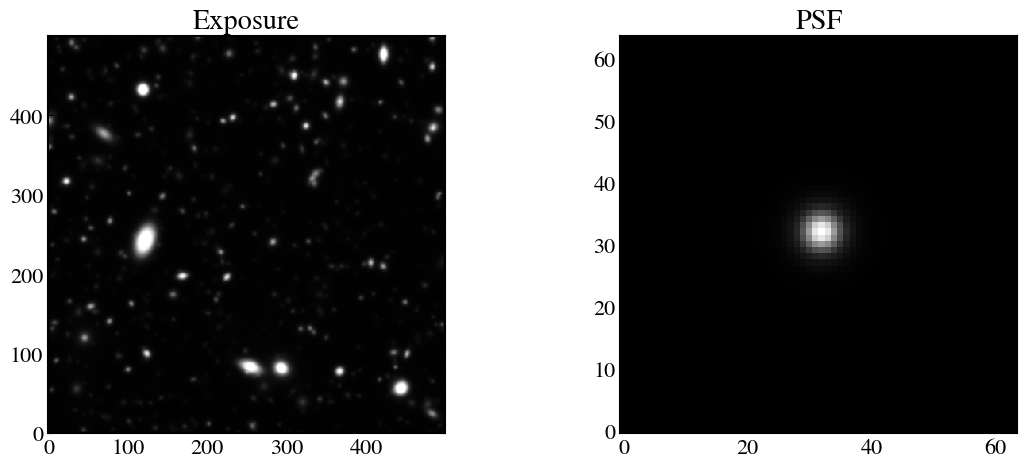

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    interpolation="None",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, vmin=-0.1, vmax=30),
)
axes[0].set_title("Exposure")
axes[1].imshow(psf_array, cmap="Greys_r", origin="lower")
axes[1].set_title("PSF")
plt.tight_layout()
plt.show()

## Build the `anacal.task.Task`

These are the same construction parameters used by
`xlens.processor.anacal.AnacalTask`. The flux-related thresholds
(`omega_f`, `v_min`, `omega_v`, `fpfs_c0`) are scaled by
`ratio = 10 ** ((mag_zero - 30) / 2.5)` to account for the photometric
zero point; with `mag_zero = 30` the ratio is 1.0.

A small `modelPrior` (on size `a` and centroid `x`) regularises the
ngmix detection fit, exactly as in the xlens task.

In [4]:
ratio = 10.0 ** ((mag_zero - 30.0) / 2.5)

prior = anacal.ngmix.modelPrior()
prior.set_sigma_a(anacal.math.qnumber(0.05))
prior.set_sigma_x(anacal.math.qnumber(0.05))

stamp_size = 64  # must match the PSF stamp size

task = anacal.task.Task(
    scale=pixel_scale,
    sigma_arcsec=0.40,   # detection/smoothing kernel size
    snr_peak_min=5.0,    # peak SNR threshold for detection
    omega_f=0.06 * ratio,
    omega_v=0.003 * ratio,   # single neighbour-difference param
    prior=prior,
    stamp_size=stamp_size,
    image_bound=40,      # drop sources within 40 pix of the boundary
    num_epochs=0,
    force_size=False,
    force_center=True,
    fpfs_c0=8.4 * ratio,
)

## Build the processing blocks

`task.process_image` works block-by-block. `anacal.geometry.get_block_list`
tiles the image into overlapping blocks; we attach the (constant) PSF to
each block. This mirrors `xlens.utils.image.get_blocks`, except that for
a spatially varying PSF you would evaluate the PSF model at each block
centre instead of reusing one constant stamp.

In [5]:
blocks = anacal.geometry.get_block_list(
    img_nx=nx,
    img_ny=ny,
    block_nx=250,
    block_ny=250,
    block_overlap=80,
    scale=pixel_scale,
)

# Constant PSF: attach the same 64x64 stamp to every block.
for bb in blocks:
    bb.psf_array = anacal.utils.resize_array(psf_array, (stamp_size, stamp_size))

print(f"number of blocks: {len(blocks)}")

number of blocks: 9


## Detect and measure in one call

With `detection=None`, `process_image` first detects sources, then runs
the FPFS measurement (`do_fpfs=True`) at the detected positions and
returns a single structured-array catalog.

In [6]:
catalog = task.process_image(
    gal_array,
    psf_array,
    variance=noise_variance,
    block_list=blocks,
    detection=None,
    noise_array=None,
    mask_array=None,
    do_fpfs=True,
)
print(f"detected and measured {len(catalog)} objects")

detected and measured 262 objects


In [7]:
catalog.dtype.names

('ra',
 'dec',
 'flux',
 'dflux_dg1',
 'dflux_dg2',
 'dflux_dj1',
 'dflux_dj2',
 't',
 'dt_dg1',
 'dt_dg2',
 'dt_dj1',
 'dt_dj2',
 'a1',
 'da1_dg1',
 'da1_dg2',
 'da1_dj1',
 'da1_dj2',
 'a2',
 'da2_dg1',
 'da2_dg2',
 'da2_dj1',
 'da2_dj2',
 'e1',
 'de1_dg1',
 'de1_dg2',
 'de1_dj1',
 'de1_dj2',
 'e2',
 'de2_dg1',
 'de2_dg2',
 'de2_dj1',
 'de2_dj2',
 'x1',
 'dx1_dg1',
 'dx1_dg2',
 'dx1_dj1',
 'dx1_dj2',
 'x2',
 'dx2_dg1',
 'dx2_dg2',
 'dx2_dj1',
 'dx2_dj2',
 'wdet',
 'dwdet_dg1',
 'dwdet_dg2',
 'dwdet_dj1',
 'dwdet_dj2',
 'wsel',
 'dwsel_dg1',
 'dwsel_dg2',
 'dwsel_dj1',
 'dwsel_dj2',
 'mask_value',
 'is_peak',
 'is_primary',
 'flux_gauss0',
 'dflux_gauss0_dg1',
 'dflux_gauss0_dg2',
 'dflux_gauss0_dj1',
 'dflux_gauss0_dj2',
 'flux_gauss2',
 'dflux_gauss2_dg1',
 'dflux_gauss2_dg2',
 'dflux_gauss2_dj1',
 'dflux_gauss2_dj2',
 'flux_gauss0_err',
 'flux_gauss2_err',
 'fpfs_e1',
 'fpfs_de1_dg1',
 'fpfs_de1_dg2',
 'fpfs_de1_dj1',
 'fpfs_de1_dj2',
 'fpfs_e2',
 'fpfs_de2_dg1',
 'fpfs_de2_dg2',
 '

### Key output columns

Positions (arcsec, relative to the image origin; divide by `pixel_scale`
for pixel coordinates):
+ `x1`, `x2`: measurement-centroid position
+ `x1_det`, `x2_det`: detection-peak position

Detection / selection weights and their shear responses:
+ `wdet`, `dwdet_dg1`, `dwdet_dg2`: detection weight
+ `wsel`, `dwsel_dg1`, `dwsel_dg2`: **selection weight** (detection weight
  combined with the shapelet selection) — this is the weight used for
  shear estimation

FPFS ellipticity and shear response:
+ `fpfs_e1`, `fpfs_de1_dg1`: ellipticity and response (first component)
+ `fpfs_e2`, `fpfs_de2_dg2`: ellipticity and response (second component)

Fluxes (Gaussian-weighted, multiple scales):
+ `flux_gauss0/2/4` and their shear responses and errors

(Unlike the legacy example, a single `Task` call uses one measurement
kernel — there is no `fpfs1_*`/`fpfs2_*`. The multi-kernel, band-prefixed
columns such as `i_fpfs1_e1` are produced by the xlens forced-measurement
stage in `MeasureCoaddsPipe`, not by a bare `Task`.)

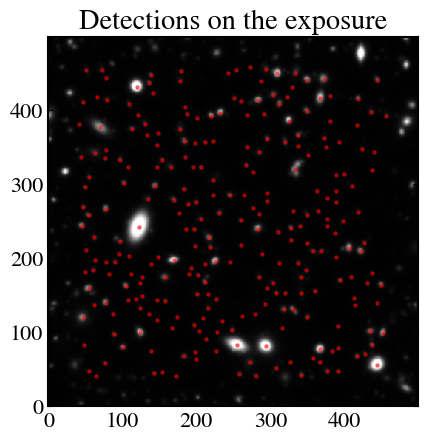

In [8]:
plt.close()
plt.scatter(
    catalog["x1"] / pixel_scale,
    catalog["x2"] / pixel_scale,
    marker="o",
    alpha=0.5,
    s=5.0,
    color="red",
)
plt.imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    interpolation="None",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, vmin=-0.1, vmax=30),
)
plt.title("Detections on the exposure")
plt.show()

## Shear estimation

Following `example4_blended_sim_measure_match.ipynb`, the shear is the
weighted ellipticity divided by its total shear response, using the
selection weight `wsel`:

$$ \hat{g}_i = \frac{\sum w_{\rm sel}\, e_i}
                    {\sum \left(\partial_{g_i} w_{\rm sel}\, e_i
                     + w_{\rm sel}\, \partial_{g_i} e_i\right)} $$

This is the new-API analogue of the legacy example, which weighted by the
detection weight `fpfs_w` (here `wsel` additionally folds in the shapelet
selection function).

In [9]:
e1 = catalog["wsel"] * catalog["fpfs_e1"]
de1_dg1 = (
    catalog["dwsel_dg1"] * catalog["fpfs_e1"]
    + catalog["wsel"] * catalog["fpfs_de1_dg1"]
)
g1 = np.sum(e1) / np.sum(de1_dg1)

e2 = catalog["wsel"] * catalog["fpfs_e2"]
de2_dg2 = (
    catalog["dwsel_dg2"] * catalog["fpfs_e2"]
    + catalog["wsel"] * catalog["fpfs_de2_dg2"]
)
g2 = np.sum(e2) / np.sum(de2_dg2)

print(f"g1 = {g1:.6f}")
print(f"g2 = {g2:.6f}")

g1 = -0.051108
g2 = -0.015119
